# 注意力线索与注意力权重

这一节先不实现完整的注意力层，而是用一张热图建立最重要的直觉：**对每个查询（query），模型都会为一组键（key）分配权重**。权重越大，表示计算当前输出时越关注对应的信息。

学习完这个示例，你应当能够：

- 说清 query、key 和注意力权重矩阵三个概念之间的关系；
- 根据张量形状判断热图的行、列分别表示什么；
- 从热图中判断注意力是集中、分散，还是只关注自身位置。

> 本 notebook 只演示注意力权重的可视化。value（值）以及用权重对 value 做加权求和，会在后续注意力实现中出现。

## 1. 从注意力线索到权重矩阵

人在观察场景时，会同时受到两类线索影响：

- **非自主性线索**：颜色、亮度、运动等显著刺激会自动吸引注意；
- **自主性线索**：当前目标会主动引导注意，例如带着“找红色杯子”的目标观察桌面。

注意力机制把第二类过程抽象成一次匹配：query 表示“我正在找什么”，key 表示“每条信息可用什么特征被匹配”。匹配结果经过归一化后形成注意力权重 $\alpha_{ij}$，其中第 $i$ 行对应第 $i$ 个 query，第 $j$ 列对应第 $j$ 个 key。

$$
A = [\alpha_{ij}] \in \mathbb{R}^{n_q \times n_k}
$$

通常每一行的权重之和为 1。随后系统会用这一行权重对各个 value 做加权求和：

$$
\mathrm{output}_i = \sum_j \alpha_{ij}v_j.
$$

因此，热图并不是最终输出，而是输出如何从输入信息中汇聚而来的可解释中间结果。

In [1]:
import torch
from d2l import torch as d2l

## 2. 热图工具如何读取四维张量

下面的 `show_heatmaps` 接收形状为

```text
(热图行数, 热图列数, query 数量, key 数量)
```

的四维张量。前两个维度决定画布上排列多少张子图；后两个维度才是一张注意力热图的高和宽。在多头注意力中，前两个维度常被用来组织不同样本或不同注意力头。

实现路径如下：

1. `subplots` 按前两个维度创建子图网格；
2. 两层 `zip` 同步遍历子图和对应矩阵；
3. `detach()` 切断自动微分图，因为这里只做展示，不需要计算梯度；
4. `numpy()` 将 CPU 张量交给 Matplotlib 的 `imshow`；
5. 颜色条把颜色深浅映射回实际权重大小。

> 调试提示：如果矩阵位于 GPU，直接 `.numpy()` 会报错，应先使用 `matrix.detach().cpu().numpy()`。当前示例创建的是 CPU 张量，所以原代码可以正常运行。

In [2]:
#@save
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """显示矩阵热图"""
    d2l.use_svg_display()
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

## 3. 先预测，再运行：单位矩阵表示什么

`torch.eye(10)` 创建一个 $10 \times 10$ 的单位矩阵：对角线为 1，其余位置为 0。`reshape((1, 1, 10, 10))` 不改变元素，只增加两个用于组织子图的维度。

最终形状的语义是：

| 维度 | 大小 | 含义 |
| --- | ---: | --- |
| 0 | 1 | 1 行热图 |
| 1 | 1 | 1 列热图 |
| 2 | 10 | 10 个 queries |
| 3 | 10 | 10 个 keys |

运行前可以先预测：第 $i$ 个 query 只给第 $i$ 个 key 权重 1，因此热图应当只有主对角线颜色最深。若把它用于 value 的加权求和，每个位置都会原样取回与自己同索引的 value。这是一种“只关注自己”的注意力模式。

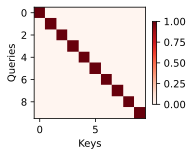

In [3]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

## 4. 读图检查点与练习

看到输出后，检查以下三点：

- 横轴是 keys，纵轴是 queries；单元格 $(i,j)$ 表示 query $i$ 对 key $j$ 的权重；
- 深色集中在主对角线，说明每个 query 都只选择同索引的 key；
- 每一行恰有一个 1，所以行和为 1，满足常见的注意力权重归一化条件。

可以通过修改矩阵来检验自己是否真正理解了读图规则：

1. 把矩阵改为 `torch.ones(10, 10) / 10`。先预测热图，再解释它为什么表示“平均关注所有 key”。
2. 使用 `torch.flip(torch.eye(10), dims=[1])`。判断深色线会出现在哪里，以及 query 0 会选择哪个 key。
3. 创建两张不同矩阵并整理成形状 `(1, 2, 10, 10)`，传入 `titles=['自身注意', '均匀注意']`，观察第二个维度如何控制子图列。

**核心结论：** 注意力权重矩阵记录了每个 query 如何在 keys 之间分配关注度；热图让这种分配模式可见。后续无论是核回归、自注意力还是多头注意力，都可以沿用这套读图方法。